In [33]:
import nltk
nltk.download("movie_reviews")

[nltk_data] Downloading package movie_reviews to C:\Users\anubhav
[nltk_data]     goyal\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


True

In [34]:
from nltk.corpus import movie_reviews
import pandas as pd



In [35]:
reviews = []
for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        text = movie_reviews.raw(fileid)
        reviews.append({"text": text, "label": category})

df = pd.DataFrame(reviews)
print(df.shape)
print(df.head())
print(df['label'].value_counts())

(2000, 2)
                                                text label
0  plot : two teen couples go to a church party ,...   neg
1  the happy bastard's quick movie review \ndamn ...   neg
2  it is movies like these that make a jaded movi...   neg
3   " quest for camelot " is warner bros . ' firs...   neg
4  synopsis : a mentally unstable man undergoing ...   neg
label
neg    1000
pos    1000
Name: count, dtype: int64


In [36]:
df['text_length'] = df['text'].apply(len)
print(df['text_length'].describe())

count     2000.000000
mean      3893.002000
std       1712.425852
min         91.000000
25%       2737.750000
50%       3622.500000
75%       4720.250000
max      14957.000000
Name: text_length, dtype: float64


In [37]:
from sklearn.model_selection import train_test_split

In [38]:
df.label.value_counts()

label
neg    1000
pos    1000
Name: count, dtype: int64

In [39]:
test_size= 0.2
train_df, val_df= train_test_split(df,stratify=df.label,test_size=test_size, random_state=1234)

In [40]:
train_df.label.value_counts()

label
neg    800
pos    800
Name: count, dtype: int64

In [41]:
val_df.label.value_counts()*int((1-test_size)/test_size)

label
neg    800
pos    800
Name: count, dtype: int64

In [42]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()
import warnings; warnings.filterwarnings("ignore")
from wordcloud import WordCloud, STOPWORDS

In [43]:
all_label=Counter(df.label)
all_label.most_common()

[('neg', 1000), ('pos', 1000)]

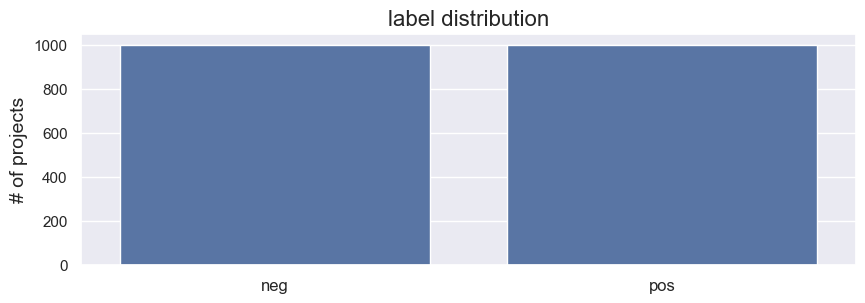

In [44]:
# Plot label frequencies
labels, label_counts = zip(*all_label.most_common())
plt.figure(figsize=(10, 3))
ax = sns.barplot(x=list(labels), y=list(label_counts))
ax.set_xticklabels(labels, rotation=0, fontsize=12)
plt.title("label distribution", fontsize=16)
plt.ylabel("# of projects", fontsize=14)
plt.show()

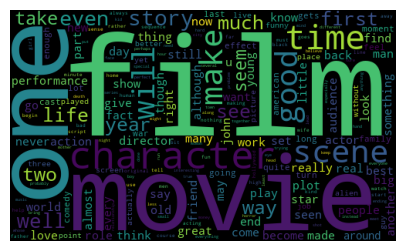

In [45]:
# Most frequent tokens for each tag
tag="pos"
plt.figure(figsize=(10, 3))
subset = df[df.label==tag]
text = subset.text.values
cloud = WordCloud(
    stopwords=STOPWORDS, background_color="black", collocations=False,
    width=500, height=300).generate(" ".join(text))
plt.axis("off")
plt.imshow(cloud)

#DATA PREPROCESSING

In [46]:
import json
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

In [47]:
nltk.download("stopwords")
STOPWORDS = stopwords.words("english")

[nltk_data] Downloading package stopwords to C:\Users\anubhav
[nltk_data]     goyal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [48]:
def clean_text(text, stopwords=STOPWORDS):
    """Clean raw text string."""
    # Lower
    text = text.lower()

    # Remove stopwords
    pattern = re.compile(r'\b(' + r"|".join(stopwords) + r")\b\s*")
    text = pattern.sub('', text)

    # Spacing and filters
    text = re.sub(r"([!\"'#$%&()*\+,-./:;<=>?@\\\[\]^_`{|}~])", r" \1 ", text)  # add spacing
    text = re.sub("[^A-Za-z0-9]+", " ", text)  # remove non alphanumeric chars
    text = re.sub(" +", " ", text)  # remove multiple spaces
    text = text.strip()  # strip white space at the ends
    text = re.sub(r"http\S+", "", text)  #  remove links

    return text

In [49]:
# Apply to dataframe
original_df = df.copy()
df.text = df.text.apply(clean_text)
print (f"{original_df.text.values[0]}\n{df.text.values[0]}")

plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
they seem to have taken this pretty neat concept , but executed it terribly . 
so what are the problems with the movie ? 
well , its main problem is that it's simply too jumbled . 
it starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience member , have no id

Label encoding

In [50]:
# Label to index
labels = train_df.label.unique().tolist()
labels
num_classes = len(labels)
class_to_index = {label: i for i, label in enumerate(labels)}
class_to_index

{'neg': 0, 'pos': 1}

In [51]:
# Encode labels
df["label"] = df["label"].map(class_to_index)
df.head()

,text,label,text_length
0,plot two teen couples go church party drink dr...,0,4043
1,happy bastard quick movie review damn y2k bug ...,0,1370
2,movies like make jaded movie viewer thankful i...,0,2848
3,quest camelot warner bros first feature length...,0,2929
4,synopsis mentally unstable man undergoing psyc...,0,4418


In [52]:
def decode(indices, index_to_class):
    return [index_to_class[index] for index in indices]

In [53]:
index_to_class = {v:k for k, v in class_to_index.items()}
decode(df.head()["label"].values, index_to_class=index_to_class)

['neg', 'neg', 'neg', 'neg', 'neg']

VADER

In [54]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    score = analyzer.polarity_scores(text)
    if score['compound'] >= 0.05:
        return 'pos'
    elif score['compound'] <= -0.05:
        return 'neg'
    else:
        return 'neu'       # VADER can predict neutral
                           # but your labels only have pos/neg
                           # we will handle this in a moment

df['vader_prediction'] = df['text'].apply(get_vader_sentiment)
print(df[['text', 'label', 'vader_prediction']].head(10))

                                                text  label vader_prediction
0  plot two teen couples go church party drink dr...      0              neg
1  happy bastard quick movie review damn y2k bug ...      0              pos
2  movies like make jaded movie viewer thankful i...      0              pos
3  quest camelot warner bros first feature length...      0              neg
4  synopsis mentally unstable man undergoing psyc...      0              neg
5  capsule 2176 planet mars police taking custody...      0              neg
6  ask 8mm eight millimeter really wholesome surv...      0              neg
7  exactly long movie felt even nine laughs nine ...      0              pos
8  call road trip walking wounded stellan skarsg ...      0              neg
9  plot young french boy sees parents killed eyes...      0              pos


In [55]:
# how many did VADER call neutral?
print(df['vader_prediction'].value_counts())

vader_prediction
pos    1461
neg     532
neu       7
Name: count, dtype: int64


In [56]:
# Encode labels
df["vader_prediction"] = df["vader_prediction"].map(class_to_index)
df.head()

,text,label,text_length,vader_prediction
0,plot two teen couples go church party drink dr...,0,4043,0.0
1,happy bastard quick movie review damn y2k bug ...,0,1370,1.0
2,movies like make jaded movie viewer thankful i...,0,2848,1.0
3,quest camelot warner bros first feature length...,0,2929,0.0
4,synopsis mentally unstable man undergoing psyc...,0,4418,0.0


In [57]:
import mlflow

In [58]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Create a mask for non-NaN values in 'vader_prediction'
valid_predictions_mask = df['vader_prediction'].notna()

# Filter both 'label' and 'vader_prediction' using the mask
y_true_filtered = df.loc[valid_predictions_mask, 'label']
y_pred_filtered = df.loc[valid_predictions_mask, 'vader_prediction'].astype(int) # Ensure int type

print(classification_report(y_true_filtered, y_pred_filtered))

              precision    recall  f1-score   support

           0       0.70      0.37      0.48       995
           1       0.57      0.84      0.68       998

    accuracy                           0.61      1993
   macro avg       0.63      0.60      0.58      1993
weighted avg       0.63      0.61      0.58      1993



In [60]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")

# tell MLflow which experiment this belongs to
mlflow.set_experiment("imdb-sentiment")

with mlflow.start_run(run_name="vader_baseline"):
    
    # --- your existing evaluation code (unchanged) ---
    accuracy = accuracy_score(y_true_filtered,y_pred_filtered)
    f1_weighted = f1_score(y_true_filtered, y_pred_filtered, 
                           average='weighted')
    f1_pos = f1_score(y_true_filtered, y_pred_filtered,
                      pos_label=1, average='binary')
    f1_neg = f1_score(y_true_filtered, y_pred_filtered,
                      pos_label=0, average='binary')
    
    # --- new MLflow lines below ---
    
    # log what settings were used
    mlflow.log_param("model_type",      "vader")
    mlflow.log_param("threshold_pos",   0.05)
    mlflow.log_param("threshold_neg",  -0.05)
    mlflow.log_param("dataset",         "imdb")
    mlflow.log_param("total_samples",   len(df))
    
    # log how well it performed
    mlflow.log_metric("accuracy",     round(accuracy, 4))
    mlflow.log_metric("f1_weighted",  round(f1_weighted, 4))
    mlflow.log_metric("f1_positive",  round(f1_pos, 4))
    mlflow.log_metric("f1_negative",  round(f1_neg, 4))
    
    # print so you can also see in notebook
    print(f"Accuracy:     {accuracy:.3f}")
    print(f"F1 weighted:  {f1_weighted:.3f}")
    print(f"F1 positive:  {f1_pos:.3f}")
    print(f"F1 negative:  {f1_neg:.3f}")
    print("Run logged to MLflow successfully!")

2026/05/28 12:02:54 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/28 12:02:54 INFO mlflow.store.db.utils: Updating database tables
2026/05/28 12:02:58 INFO mlflow.tracking.fluent: Experiment with name 'imdb-sentiment' does not exist. Creating a new experiment.


Accuracy:     0.605
F1 weighted:  0.582
F1 positive:  0.680
F1 negative:  0.485
Run logged to MLflow successfully!


In [61]:
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("imdb-sentiment")

with mlflow.start_run(run_name="test_run"):
    mlflow.log_metric("test_metric", 1.0)
    print("success - check localhost:5000 now")

success - check localhost:5000 now
